In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 1. Building a Basic VAE  in PyTorch

In [2]:
batch_size, lr, epochs,  latent_dim = 128, 1e-3, 10, 20

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 400),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_log_var = nn.Linear(400, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28*28)
        )

    def encode(self, x):
        x = x.view(-1, 28*28)
        h = self.encoder(x)

        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)

        return mu, log_var

    def reparameterize(self, mu, log_var):

        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)

        return mu + std * eps

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstruction_logits = self.decode(z)

        return reconstruction_logits, mu, log_var

In [4]:
def vae_loss(reconstruction_logits, x, mu, log_var):
    x = x.view(-1, 28*28)

    reconstruction_loss = nn.functional.binary_cross_entropy_with_logits(
        reconstruction_logits,
        x,
        reduction="sum"
    )

    kl_divergence = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp()
    )

    return reconstruction_loss + kl_divergence, reconstruction_loss, kl_divergence

In [5]:
model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

train_losses = []

for epoch in range(1, epochs+1):
    model.train()
    total_loss, total_reconstruction, total_kl = 0, 0, 0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()

        reconstruction_logits, mu, log_var = model(images)
        loss, reconstruction_loss, kl_divergence = vae_loss(
            reconstruction_logits, images, mu, log_var
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_reconstruction += reconstruction_loss.item()
        total_kl += kl_divergence.item()

    avg_loss = total_loss / len(train_dataset)
    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Reconstruction: {total_reconstruction / len(train_dataset):.4f} | "
        f"KL: {total_kl / len(train_dataset):.4f}"
    )

Epoch 01/10 | Loss: 163.8291 | Reconstruction: 148.3011 | KL: 15.5280
Epoch 02/10 | Loss: 121.5962 | Reconstruction: 99.2082 | KL: 22.3880
Epoch 03/10 | Loss: 114.4735 | Reconstruction: 90.4726 | KL: 24.0009
Epoch 04/10 | Loss: 111.5821 | Reconstruction: 87.0117 | KL: 24.5704
Epoch 05/10 | Loss: 109.7997 | Reconstruction: 85.0373 | KL: 24.7624
Epoch 06/10 | Loss: 108.6724 | Reconstruction: 83.7641 | KL: 24.9083
Epoch 07/10 | Loss: 107.8460 | Reconstruction: 82.8174 | KL: 25.0286
Epoch 08/10 | Loss: 107.2201 | Reconstruction: 82.1207 | KL: 25.0994
Epoch 09/10 | Loss: 106.6635 | Reconstruction: 81.4967 | KL: 25.1667
Epoch 10/10 | Loss: 106.2188 | Reconstruction: 81.0291 | KL: 25.1897


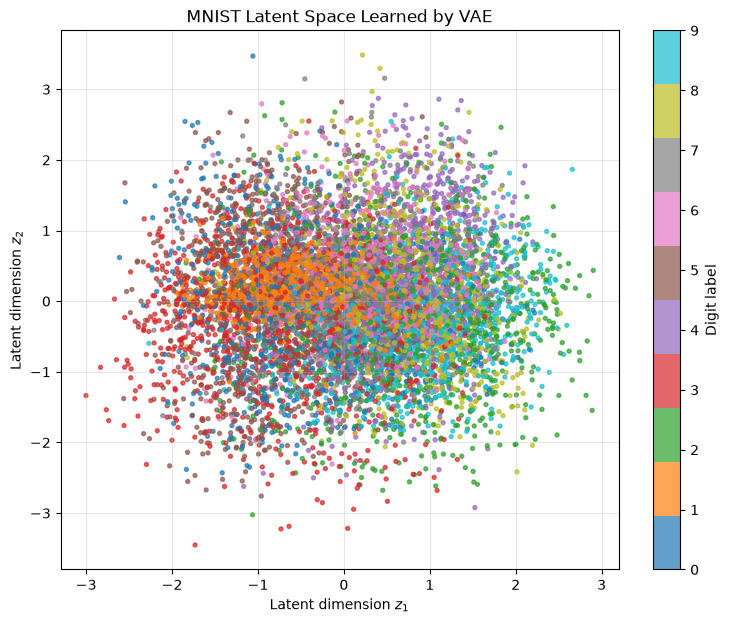

In [6]:
model.eval()

latent_means = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        mu, _ = model.encode(images)

        latent_means.append(mu.cpu())
        all_labels.append(labels)

latent_means = torch.cat(latent_means).numpy()
all_labels = torch.cat(all_labels).numpy()

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    latent_means[:, 0],
    latent_means[:, 1],
    c=all_labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("Latent dimension $z_1$")
plt.ylabel("Latent dimension $z_2$")
plt.title("MNIST Latent Space Learned by VAE")
plt.grid(True, alpha=0.3)
plt.show()

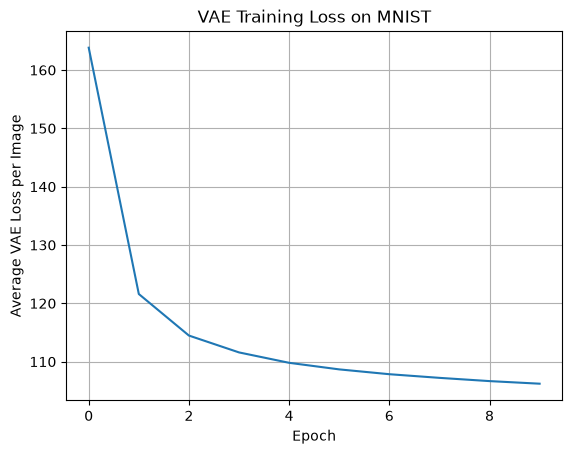

In [7]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Average VAE Loss per Image")
plt.title("VAE Training Loss on MNIST")
plt.grid(True)
plt.show()

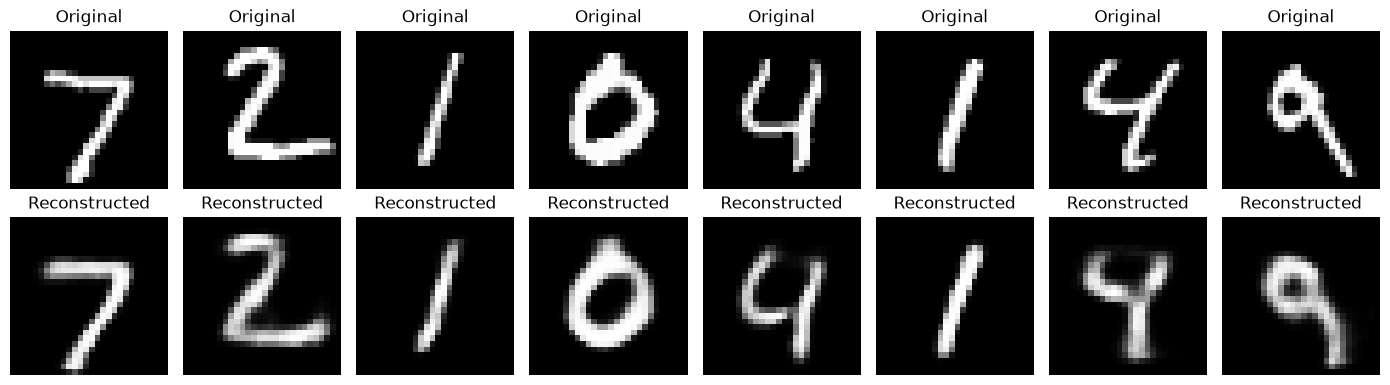

In [8]:
model.eval()

images, _ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstruction_logits, _, _ = model(images)
    reconstructed_images = torch.sigmoid(reconstruction_logits)
    reconstructed_images = reconstructed_images.view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i in range(8):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap="gray")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed_images[i].cpu().squeeze(), cmap="gray")
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

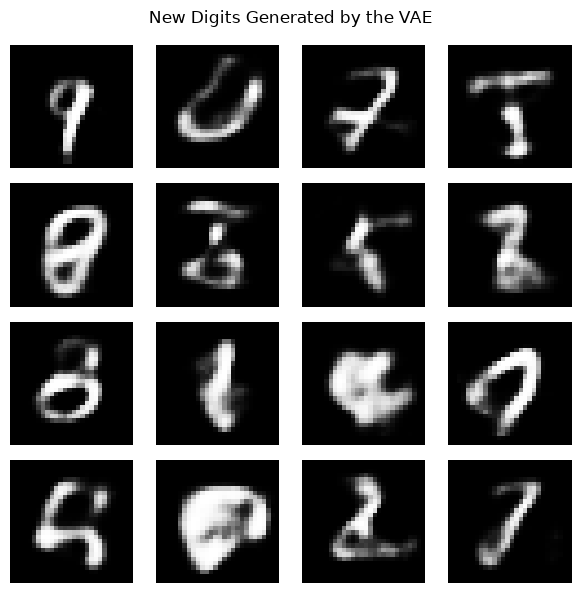

In [9]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated_logits = model.decode(z)
    generated_images = torch.sigmoid(generated_logits)
    generated_images = generated_images.view(-1, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].cpu(), cmap="gray")
    ax.axis("off")

plt.suptitle("New Digits Generated by the VAE")
plt.tight_layout()
plt.show()

## 2. Analyzing VAE Performance

In [10]:
latent_dim = 2
model2 = VAE(latent_dim=latent_dim).to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=lr)


train_losses = []

for epoch in range(1, epochs+1):
    model2.train()
    total_loss, total_reconstruction, total_kl = 0, 0, 0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer2.zero_grad()

        reconstruction_logits, mu, log_var = model2(images)
        loss, reconstruction_loss, kl_divergence = vae_loss(
            reconstruction_logits, images, mu, log_var
        )

        loss.backward()
        optimizer2.step()

        total_loss += loss.item()
        total_reconstruction += reconstruction_loss.item()
        total_kl += kl_divergence.item()

    avg_loss = total_loss / len(train_dataset)
    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Reconstruction: {total_reconstruction / len(train_dataset):.4f} | "
        f"KL: {total_kl / len(train_dataset):.4f}"
    )

Epoch 01/10 | Loss: 189.6803 | Reconstruction: 183.7255 | KL: 5.9548
Epoch 02/10 | Loss: 167.6685 | Reconstruction: 162.5358 | KL: 5.1327
Epoch 03/10 | Loss: 163.7231 | Reconstruction: 158.4612 | KL: 5.2619
Epoch 04/10 | Loss: 161.5141 | Reconstruction: 156.1389 | KL: 5.3752
Epoch 05/10 | Loss: 159.8580 | Reconstruction: 154.4192 | KL: 5.4388
Epoch 06/10 | Loss: 158.5345 | Reconstruction: 153.0142 | KL: 5.5203
Epoch 07/10 | Loss: 157.4730 | Reconstruction: 151.8750 | KL: 5.5980
Epoch 08/10 | Loss: 156.5700 | Reconstruction: 150.9212 | KL: 5.6489
Epoch 09/10 | Loss: 155.7940 | Reconstruction: 150.1019 | KL: 5.6922
Epoch 10/10 | Loss: 155.0495 | Reconstruction: 149.3200 | KL: 5.7294


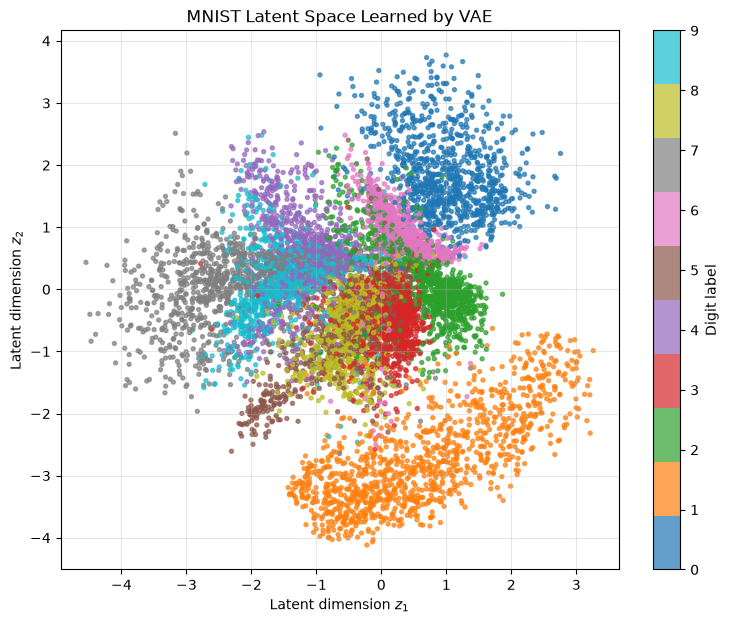

In [11]:
model2.eval()

latent_means = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        mu, _ = model2.encode(images)

        latent_means.append(mu.cpu())
        all_labels.append(labels)

latent_means = torch.cat(latent_means).numpy()
all_labels = torch.cat(all_labels).numpy()

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    latent_means[:, 0],
    latent_means[:, 1],
    c=all_labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("Latent dimension $z_1$")
plt.ylabel("Latent dimension $z_2$")
plt.title("MNIST Latent Space Learned by VAE")
plt.grid(True, alpha=0.3)
plt.show()

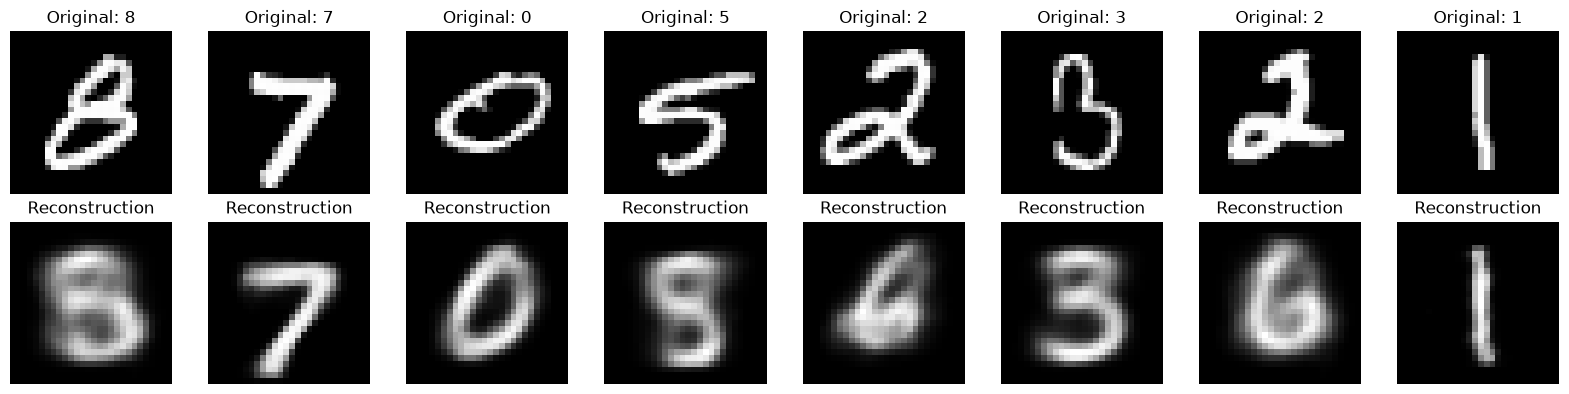

In [12]:
model2.eval()

num_images = 8
random_indices = torch.randperm(len(test_dataset))[:num_images]

original_images = torch.stack([test_dataset[i][0] for i in random_indices]).to(device)
labels = [test_dataset[i][1] for i in random_indices]

with torch.no_grad():
    reconstruction_logits, _, _ = model2(original_images)
    reconstructed_images = torch.sigmoid(reconstruction_logits)
    reconstructed_images = reconstructed_images.view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, num_images, figsize=(16, 4))

for i in range(num_images):
    axes[0, i].imshow(original_images[i].cpu().squeeze(), cmap="gray")
    axes[0, i].set_title(f"Original: {labels[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed_images[i].cpu().squeeze(), cmap="gray")
    axes[1, i].set_title("Reconstruction")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

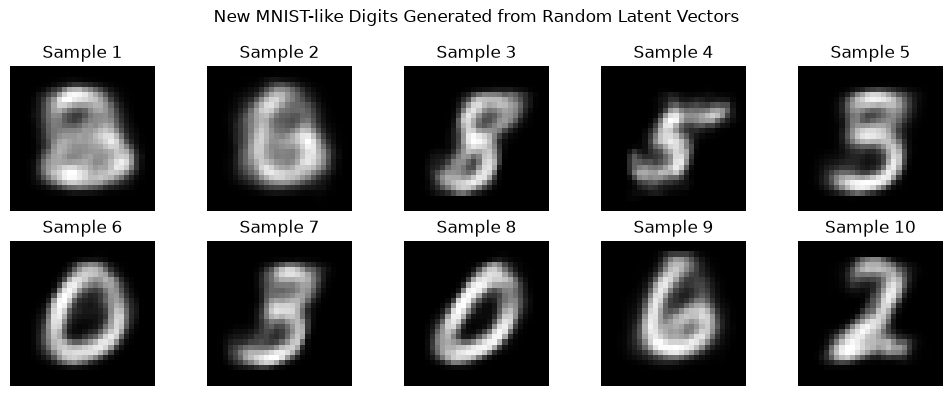

In [13]:
model2.eval()

num_samples = 10

with torch.no_grad():
    z = torch.randn(num_samples, latent_dim).to(device)
    generated_logits = model2.decode(z)
    generated_images = torch.sigmoid(generated_logits)
    generated_images = generated_images.view(-1, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].cpu(), cmap="gray")
    ax.set_title(f"Sample {i + 1}")
    ax.axis("off")

plt.suptitle("New MNIST-like Digits Generated from Random Latent Vectors")
plt.tight_layout()
plt.show()

## 3. Comparing with Doersch's VAE Implementation

In [16]:
def evaluate_vae(model, data_loader):
    model.eval()

    total_loss = 0
    total_bce = 0
    total_kl = 0

    with torch.no_grad():
        for images, _ in data_loader:
            images = images.to(device)

            reconstruction_logits, mu, log_var = model(images)

            loss, bce, kl = vae_loss(
                reconstruction_logits,
                images,
                mu,
                log_var
            )

            total_loss += loss.item()
            total_bce += bce.item()
            total_kl += kl.item()

    dataset_size = len(data_loader.dataset)

    return {
        "total_loss": total_loss / dataset_size,
        "reconstruction_loss": total_bce / dataset_size,
        "kl_divergence": total_kl / dataset_size
    }

In [17]:
results_20d = evaluate_vae(model, test_loader)
results_2d = evaluate_vae(model2, test_loader)

print("20D VAE Results")
print(f"Test VAE loss: {results_20d['total_loss']:.4f}")
print(f"Reconstruction loss: {results_20d['reconstruction_loss']:.4f}")
print(f"KL divergence: {results_20d['kl_divergence']:.4f}")

print("\n2D VAE Results")
print(f"Test VAE loss: {results_2d['total_loss']:.4f}")
print(f"Reconstruction loss: {results_2d['reconstruction_loss']:.4f}")
print(f"KL divergence: {results_2d['kl_divergence']:.4f}")

20D VAE Results
Test VAE loss: 105.5749
Reconstruction loss: 80.0726
KL divergence: 25.5023

2D VAE Results
Test VAE loss: 155.1617
Reconstruction loss: 149.3064
KL divergence: 5.8553


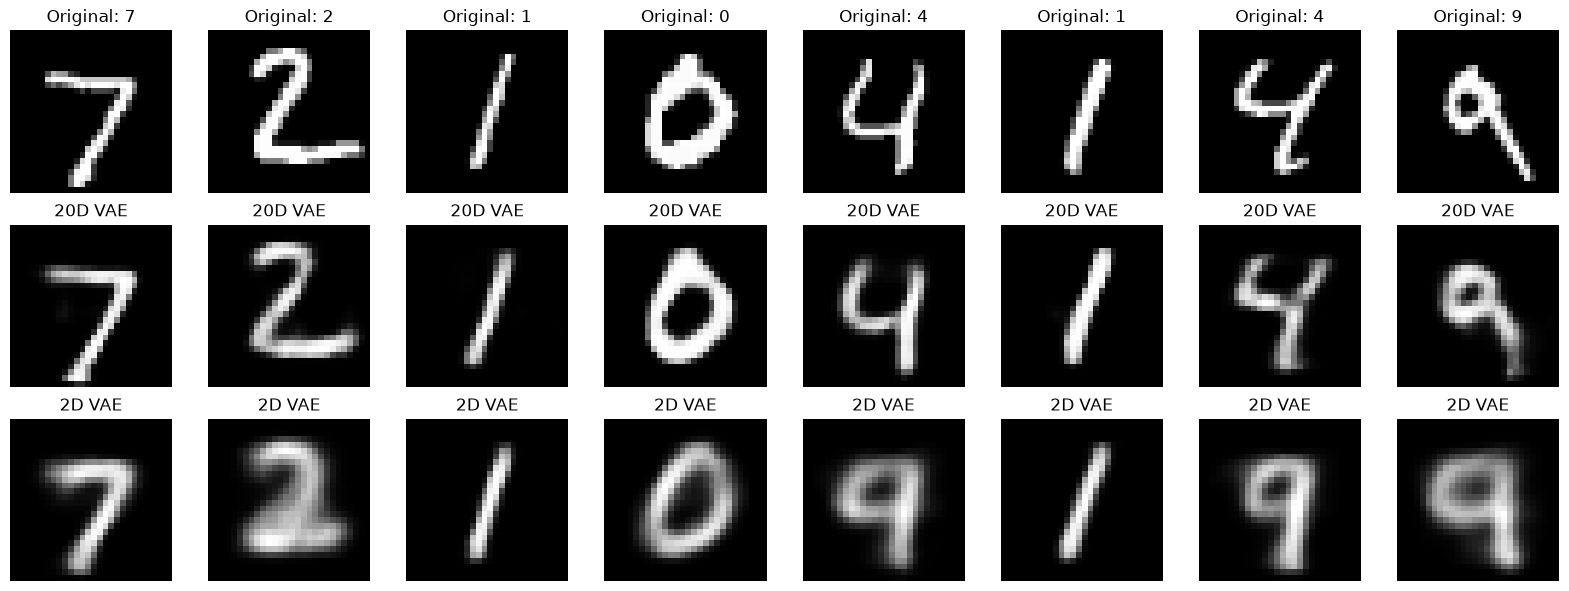

In [19]:
model.eval()
model2.eval()

images, labels = next(iter(test_loader))
images = images[:8].to(device)
labels = labels[:8]

with torch.no_grad():
    logits_20d, _, _ = model(images)
    reconstructions_20d = torch.sigmoid(logits_20d).view(-1, 28, 28)

    logits_2d, _, _ = model2(images)
    reconstructions_2d = torch.sigmoid(logits_2d).view(-1, 28, 28)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for i in range(8):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap="gray")
    axes[0, i].set_title(f"Original: {labels[i].item()}")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructions_20d[i].cpu(), cmap="gray")
    axes[1, i].set_title("20D VAE")
    axes[1, i].axis("off")

    axes[2, i].imshow(reconstructions_2d[i].cpu(), cmap="gray")
    axes[2, i].set_title("2D VAE")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

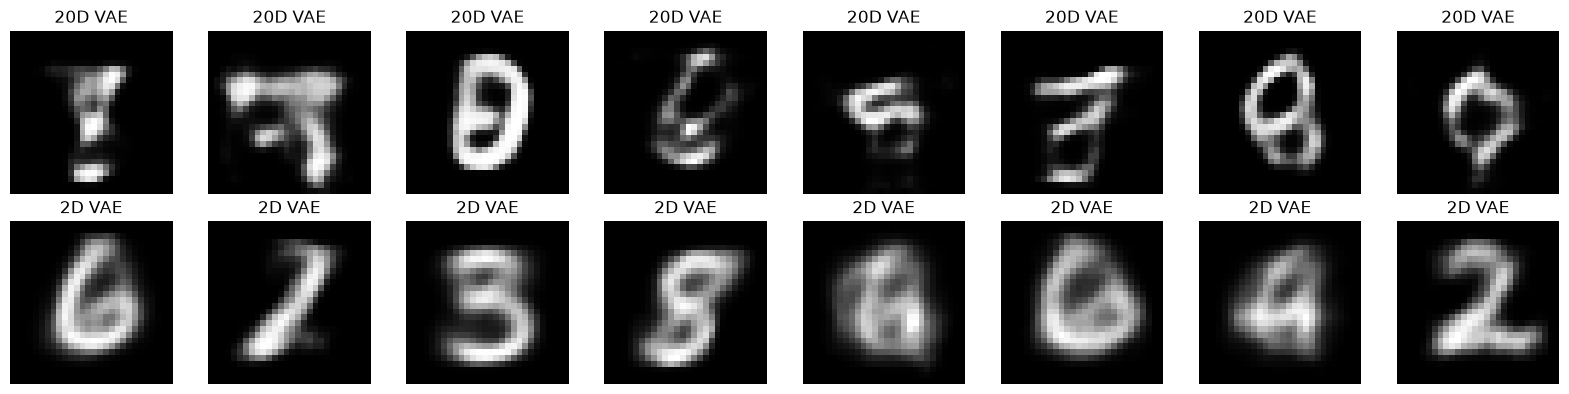

In [20]:
with torch.no_grad():
    z_20d = torch.randn(8, 20).to(device)
    generated_20d = torch.sigmoid(model.decode(z_20d)).view(-1, 28, 28)

    z_2d = torch.randn(8, 2).to(device)
    generated_2d = torch.sigmoid(model2.decode(z_2d)).view(-1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    axes[0, i].imshow(generated_20d[i].cpu(), cmap="gray")
    axes[0, i].set_title("20D VAE")
    axes[0, i].axis("off")

    axes[1, i].imshow(generated_2d[i].cpu(), cmap="gray")
    axes[1, i].set_title("2D VAE")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()